In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.colors as mcolors
from matplotlib import rc
import matplotlib.gridspec as gridspec
from fonts_config import set_computer_modern, truncate_colormap
set_computer_modern()
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from PIL import Image
from matplotlib.colors import LogNorm
from matplotlib.animation import FuncAnimation, FFMpegWriter
import matplotlib as mpl
mpl.rcParams['axes.unicode_minus'] = False

In [4]:
# ----------------------------------------------------------------------------
# Paths
# ----------------------------------------------------------------------------
n_best= 2572
best1=xr.open_dataset(f"/p/projects/megarun/luciagu/data/tabone2024/ensemble_reduced/{n_best}/yelmo1D.nc")
best=xr.open_dataset(f"/p/projects/megarun/luciagu/data/tabone2024/ensemble_reduced/{n_best}/yelmo2D_reduced.nc")
sim=best.sel(time=0)

obs = xr.open_dataset("/p/projects/megarun/ice_data/Greenland/GRL-8KM/GRL-8KM_TOPO-M17.nc")
rg=xr.open_dataset("/p/projects/megarun/luciagu/data/lauritzen2025/Greenland_Basins_PS_v1.4.2_8km.nc")
obs_v = xr.open_dataset("/p/projects/megarun/ice_data/Greenland/GRL-8KM/GRL-8KM_VEL.nc")

h1 =sim.H_ice
h2 = obs.H_ice
x = h1.values.flatten()
y = h2.values.flatten()
m = rg.mask.values.flatten()
mask = np.isfinite(x) & np.isfinite(y) & (m!=0)
x, y = x[mask], y[mask]
# diff = (sim.H_ice.values - obs.H_ice.values)**2
diff = (x - y)**2
rmse_H = np.sqrt(diff.mean()) # mean in x and y

v1 =sim.uxy_s
v2 = obs_v.uxy_srf
x = v1.values.flatten()
y = v2.values.flatten()
mask = np.isfinite(x) & np.isfinite(y) & (m!=0)
x, y = x[mask], y[mask]
# diff = (sim.H_ice.values - obs.H_ice.values)**2
diff = (x - y)**2
rmse_v = np.sqrt(diff.mean()) # mean in x and y

In [3]:
rmse_v

np.float64(99.67259439832884)

In [5]:
 # Colormaps
colors = ["#ffffff", "#a8a8a8", "#000000"]

# Crear un colormap interpolado con 10 niveles
uxy_s_map = truncate_colormap(plt.get_cmap('gray_r'), minval=0, maxval=0.9)

zmap = mcolors.LinearSegmentedColormap.from_list("zmap", [
            (0.0, "#5E88AA"),
            (0.499, "#ADC3CF"),
            (0.50, "#024224"),
            (1.0, "#b18b5d")])

In [6]:
def pd_plot(ax,sim,uxy_s_map,zmap):
    xc=sim.xc
    yc=sim.yc
    z_bed=sim.z_bed*1e-3
    z_srf=sim.z_bed+sim.H_ice
    ice=xr.where((sim.f_grnd==1)&(sim.H_ice>0), 1, 0)
    log_uxy = sim.uxy_s.where(sim.H_ice>0) + 1e-8

    # Dibujar mapas
    bat = ax.pcolormesh(xc, yc, z_bed, cmap=zmap, vmin=-3, vmax=3)
    vel = ax.contourf(xc, yc, log_uxy, levels = np.logspace(0,3,10) ,  norm = LogNorm(), cmap = uxy_s_map,extend='both')
    # ice = ax.contourf(xc, yc, ice, colors=['White'],levels=np.linspace(0.5, 1.2, 2))

    # # Contornos
    cs1 = ax.contour(xc, yc, z_srf, levels=np.arange(150, 3600, 500), colors='black', alpha=0.3)
    cs2 = ax.contour(xc, yc, z_srf, levels=np.arange(150, 4150, 1000), colors='black')

    
    ax.set_title(f"(a) Yelmox #{n_best}")
    ax.set_aspect(1)
    ax.tick_params(labelbottom=False, labelleft=False)
    return bat, vel

def diff_plot(ax,sim,rmse_H):
    obs = xr.open_dataset("/p/projects/megarun/ice_data/Greenland/GRL-8KM/GRL-8KM_TOPO-M17.nc")
    xc=sim.xc
    yc=sim.yc
    z_bed=sim.z_bed*1e-3
    z_srf=sim.z_bed+sim.H_ice
    diff = sim.H_ice.values - obs.H_ice.values

    # Dibujar mapas
    im_diff = ax.contourf(xc, yc, diff, levels=np.linspace(-1300,1300,10),cmap = "bwr",extend='both')

    # # Contornos
    cs1 = ax.contour(xc, yc, z_srf, levels=np.arange(0, 100, 1), colors='black',linewidths=0.4)
   
    ax.set_title(f"(c) Ice thickness error")
    ax.text(0.75, 0.05, f"RMSE\n{rmse_H:.1f}m", ha='center', va='center', transform=ax.transAxes)
    ax.set_aspect(1)
    ax.tick_params(labelbottom=False, labelleft=False)
    return im_diff

def obs_plot(ax,uxy_s_map,zmap):
    sim = xr.open_dataset("/p/projects/megarun/ice_data/Greenland/GRL-8KM/GRL-8KM_TOPO-M17.nc")
    obs_v = xr.open_dataset("/p/projects/megarun/ice_data/Greenland/GRL-8KM/GRL-8KM_VEL.nc")

    xc=sim.xc
    yc=sim.yc
    z_bed=sim.z_bed*1e-3
    z_srf=sim.z_bed+sim.H_ice
    log_uxy = obs_v.uxy_srf.where(sim.H_ice>0) + 1e-8

    # Dibujar mapas
    bat = ax.pcolormesh(xc, yc, z_bed, cmap=zmap, vmin=-3, vmax=3)
    vel = ax.contourf(xc, yc, log_uxy, levels = np.logspace(0,3,10) ,  norm = LogNorm(), cmap = uxy_s_map,extend='both')

    # # Contornos
    cs1 = ax.contour(xc, yc, z_srf, levels=np.arange(150, 3600, 500), colors='black', alpha=0.3)
    cs2 = ax.contour(xc, yc, z_srf, levels=np.arange(150, 4150, 1000), colors='black')

    
    ax.set_title(f"(b) Observations")
    ax.set_aspect(1)
    ax.tick_params(labelbottom=False, labelleft=False)
    return bat, vel

/tmp/ipykernel_474514/3264903574.py:46: UserWarning: Using the axes or figure transform requires a bounding box in the respective coordinates. Using bbox_to_anchor=(0, 0, 1, 1) now.
  axins = inset_axes( ax4,
/tmp/ipykernel_474514/3264903574.py:57: UserWarning: Using the axes or figure transform requires a bounding box in the respective coordinates. Using bbox_to_anchor=(0, 0, 1, 1) now.
  axins = inset_axes( ax4,
/tmp/ipykernel_474514/3264903574.py:68: UserWarning: Using the axes or figure transform requires a bounding box in the respective coordinates. Using bbox_to_anchor=(0, 0, 1, 1) now.
  axins = inset_axes( ax4,
/tmp/ipykernel_474514/3264903574.py:79: UserWarning: Using the axes or figure transform requires a bounding box in the respective coordinates. Using bbox_to_anchor=(0, 0, 1, 1) now.
  axins = inset_axes( ax4,


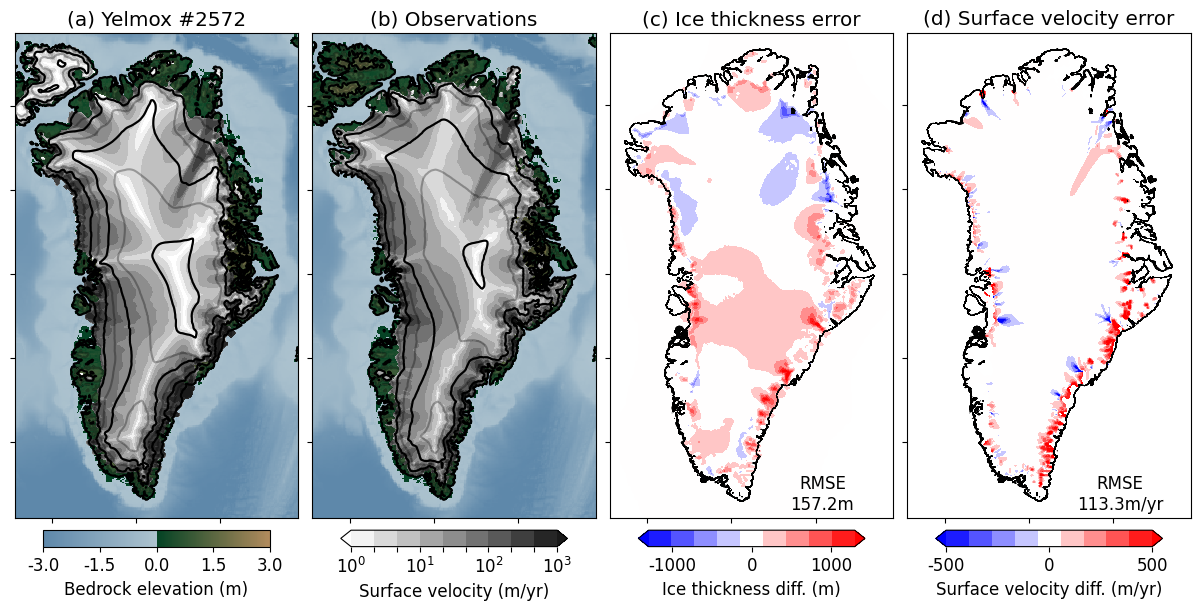

In [7]:
def diff_plot2(ax,sim,rmse_H):
    obs = xr.open_dataset("/p/projects/megarun/ice_data/Greenland/GRL-8KM/GRL-8KM_TOPO-M17.nc")
    obs_v = xr.open_dataset("/p/projects/megarun/ice_data/Greenland/GRL-8KM/GRL-8KM_VEL.nc")

    xc=sim.xc
    yc=sim.yc
    z_bed=sim.z_bed*1e-3
    z_srf=sim.z_bed+sim.H_ice
    diff = sim.uxy_s.values - obs_v.uxy_srf.values

    # Dibujar mapas
    im_diff = ax.contourf(xc, yc, diff, levels=np.linspace(-500,500,10),cmap = "bwr",extend='both')

    # # Contornos
    cs1 = ax.contour(xc, yc, z_srf, levels=np.arange(0, 100, 1), colors='black',linewidths=0.4)
   
    ax.set_title(f"(d) Surface velocity error")
    ax.text(0.75, 0.05, f"RMSE\n{rmse_H:.1f}m/yr", ha='center', va='center', transform=ax.transAxes)
    ax.set_aspect(1)
    ax.tick_params(labelbottom=False, labelleft=False)
    return im_diff

fig = plt.figure(figsize=(12, 6.1))

gs = gridspec.GridSpec(2, 4,height_ratios=[7, 1])
#  H_ice ---------------------------------------------------------------------
ax1 = plt.subplot(gs[0, 0])
bed,vel=pd_plot(ax1,sim,uxy_s_map,zmap)

ax1 = plt.subplot(gs[0, 1])
obs_plot(ax1,uxy_s_map,zmap)

ax1 = plt.subplot(gs[0, 2])
err = diff_plot(ax1,sim.where(rg.mask!=0),rmse_H)

ax1 = plt.subplot(gs[0, 3])
err2 = diff_plot2(ax1,sim.where(rg.mask!=0),rmse_v)


# Legend and colorbars ------------------------------------------------------

# Leyenda

ax4 = plt.subplot(gs[1, 0])
ax4.axis('off')
axins = inset_axes( ax4,
width="80%",  
height="20%", 
loc="center",
bbox_transform=ax4.transAxes,
borderpad=0)
cb = plt.colorbar(bed, cax=axins, orientation='horizontal', ticks=[-3,-1.5,0,1.5,3])
cb.set_label('Bedrock elevation (m)')

ax4 = plt.subplot(gs[1, 1])
ax4.axis('off')
axins = inset_axes( ax4,
width="80%",  
height="20%", 
loc="center",
bbox_transform=ax4.transAxes,
borderpad=0)
cb = plt.colorbar(vel, cax=axins, orientation='horizontal',)
cb.set_label('Surface velocity (m/yr)')

ax4 = plt.subplot(gs[1, 2])
ax4.axis('off')
axins = inset_axes( ax4,
width="80%",  
height="20%", 
loc="center",
bbox_transform=ax4.transAxes,
borderpad=0)
cb = plt.colorbar(err, cax=axins, orientation='horizontal',ticks=[-1000,0,1000])
cb.set_label('Ice thickness diff. (m)')

ax4 = plt.subplot(gs[1, 3])
ax4.axis('off')
axins = inset_axes( ax4,
width="80%",  
height="20%", 
loc="center",
bbox_transform=ax4.transAxes,
borderpad=0)
cb = plt.colorbar(err2, cax=axins, orientation='horizontal',ticks=[-500,0,500])
cb.set_label('Surface velocity diff. (m/yr)')
plt.subplots_adjust(
        left=0.01,   # Margen izquierdo
        right=0.99,  # Margen derecho
        top=1,    # Margen superior
        bottom=0.03,  # Margen inferior
        wspace=0.05,  
        hspace=-0.2   
        )
plt.savefig(f"../figs_final/fig9_{n_best}_present_day2.png",dpi=300)
# plt.close()


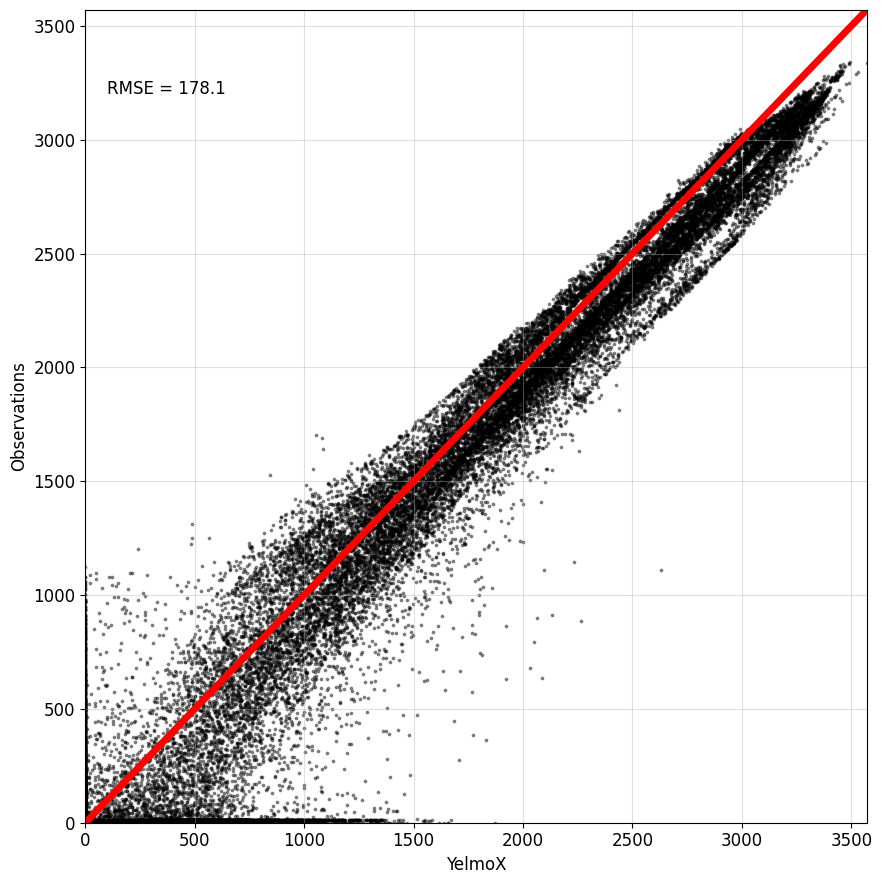

In [9]:
obs = xr.open_dataset("/p/projects/megarun/ice_data/Greenland/GRL-8KM/GRL-8KM_TOPO-M17.nc")

h1 = sim.H_ice
h2 = obs.H_ice
x = h1.values.flatten()
y = h2.values.flatten()
mask = np.isfinite(x) & np.isfinite(y)
x, y = x[mask], y[mask]
diff = (sim.H_ice.values - obs.H_ice.values)**2
rmse_H = np.sqrt(diff.mean()) # mean in x and y

# Crear figura
fig, ax = plt.subplots(figsize=(9, 9))

# Scatter plot
sc = ax.scatter(x, y, s=3, alpha=0.4, color="black")

# Línea identidad (y = x)
lims = [
    min(np.nanmin(x), np.nanmin(y)),
    max(np.nanmax(x), np.nanmax(y))
]
ax.plot(lims, lims, color="red", lw=5, label='y = x')
ax.text(100,3200, f"RMSE = {rmse_H:.1f}")

# Ejes y estilo
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("YelmoX")
ax.set_ylabel("Observations")

plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [10]:
obs = xr.open_dataset("/p/projects/megarun/ice_data/Greenland/GRL-8KM/GRL-8KM_TOPO-M17.nc")

diff = (sim.H_ice.values - obs.H_ice.values)**2
rmse_H = np.sqrt(diff.mean()) # mean in x and y
rmse_H

np.float32(178.14496)

In [65]:
diff.mean(axis=1).mean(axis=1).shape

(90,)

In [49]:
(diff.flatten()).sum()/76171

np.float32(84021.98)

In [50]:
diff.mean()

np.float32(84021.98)

In [88]:
A_obs=1.7
V_obs=7.4

s=best1.sel(time=0)
A_diff = s.A_ice_g.values - A_obs
V_diff = s.V_sle.values - V_obs
print(A_diff/A_obs*100)
print(V_diff/V_obs*100)

6.928935
6.7109547


In [89]:
s.V_sle.values

array(7.8966107, dtype=float32)